## Guide to practical estimation of structure functions from data

Next steps

- Plot slope envelope for block-bootstrapping
- Implement wavelet leader bootstrap
- add binning (Friedman-Draconis?)
- add weighted linear regression to naive lag-dependent bootstrap
- compare this with results of residual bootstrapping


### Why bother with SFs in the first place?

**Why structure functions in general?** They can be easily generalized across multiple orders, allowing for more detailed study of scaling behaviour, and in particular, the study of  intermittency via scale-dependent kurtosis.

**Why (de-biased) *second-order* structure functions in place of power spectra?**

- More robust to violations of stationarity
- Smoother
- Can handle gaps (up to a certain point)
- etc. 

### Dealing with uncertainty

*For theoretical details and Python implementation on both simulated and real-world solar wind data, see remainder of this notebook*

1. **Account for (the random component of) measurement error** $\pm\sigma_{err}$ by subtracting the resultant bias: $S_2^{true}(\tau)=S_2^{obs}(\tau)-2\sigma^2_{err}$. Failure to do so will result in a flattening at low frequencies and therefore slopes that are too shallow. Note that this correction assumes that the random error is additive white noise that is independent of the signal.
    
    Additionally, if the systematic component of the measurement error is non-constant (i.e. calibration drift), a de-trending or high-pass filter may be required to remove these artificial low frequencies from the data ([Huang 2014](https://doi.org/10.1080/14685248.2014.891739)).

    [Chhibber et al. (2018)](https://agupubs.onlinelibrary.wiley.com/doi/pdf/10.1029/2018JA025768#page=12.67) looked at the effect of FGM instrument noise on the kurtosis in their Appendix A, as did [Roberts et al. (2021)](https://doi.org/10.1029/2021JA029483) in their Appendices, comparing the effects of low and high frequency noise on time and spatial lags.

2. **Account for sampling error** by calculating a bootstrapped confidence interval for the derived statistic of interest (e.g., inertial range slope) using one of the following methods:
    - For the most complex yet statistically robust method, use the **wavelet (block) bootstrap** method described by [Wendt et al. (2007)](https://ieeexplore.ieee.org/document/4286563). Note that this method requires evenly-sampled data.
    - For a quicker method that can handle gaps, use **residual bootstrapping** of the fitted regression line. You will need to make sure that the residuals are reasonably uncorrelated and stationary. *cite*
    - For a somewhat more complex method that also gives the spread of the curves, not just the derived statistics, use **block bootstrapping** of the original time series. For turbulence applications (none in solar wind, that I found), see [Belange et al. (2023)](https://link.springer.com/article/10.1007/s00348-023-03704-w), [Theunissen et al. (2007)](https://link.springer.com/article/10.1007/s00348-007-0418-8), and [Garcia et al. (2005)](https://link.springer.com/article/10.1007/s00348-005-0091-8). Watch out for the block length (should be $\approx\lambda_C$) and points near block transitions.

*What happens when downsampling the time series? Binning lags? Something about the Freedman-Diaconis rule when choosing bin sizes...*

### Dealing with gaps

See elite work by D. Wrench

### Converting to an equivalent spectrum

See mid work by M. Bishop

### Choosing a suitable interval length

For this we must consider the following:

- Desired range of scales
- Stationarity and convergence of statistics: [Dudok de Wit et al. (2004)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.70.055302), [Kiyani et al. (2009)](https://scholar.google.com/scholar_url?url=https://journals.aps.org/pre/abstract/10.1103/PhysRevE.79.036109&hl=en&sa=T&oi=gsr-r&ct=res&cd=0&d=2750058327989828896&ei=5Ez_Z770FJGu6rQPyMPCuAs&scisig=AFWwaeb-9Mc5aBKqvPIk-kslCK3W), [Isaacs et al. (2015)](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1002/2014ja020661), [Thomson & Vernon (2015)](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=7579159&casa_token=gCXYdyKzP8AAAAAA:SMQUbjW2vlsg8-71VpfIb_f9-j41SR5VaT-ScuGil7azpKcWViFQqBgon0dXrFTgr-HSmpMNNpA&tag=1), [Jagarlamudi et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/aaef2e/meta)
- Influence of outliers: [Kiyani et al. (2006)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.74.051122) *TLDR: strong influence of outliers on scaling exponents can be reduced by removing the most extreme ones. Has been employed in SW studies, e.g. Roberts et al. (2020)*

---

# In-depth examination of uncertainty

With examples on simulated and solar wind data

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal

from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Demo datasets

1. **Simulated data:** Fractional Brownian motion with a Hurst parameter of $H=1/3$, which gives our K41 scaling.

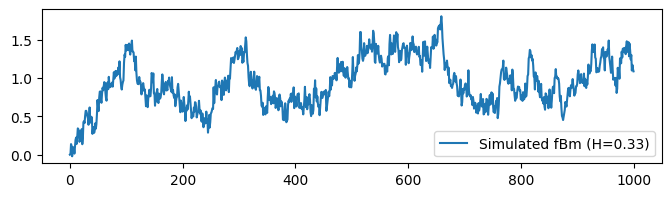

In [2]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 1000  # Number of points

hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()

# Simulate AR(1) process
# phi = 0.9
# noise = np.random.normal(0, 1, n)
# ts_sim = np.zeros(n)
# for i in range(1, n):
#     ts_sim[i] = phi * ts_sim[i - 1] + noise[i]
plt.figure(figsize=(8, 2))
plt.plot(ts_sim, label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

2. **Solar wind data:** Magnetic measurements of the LISM from Voyager 1. Uncertainties are as follows (from [Burlaga et al. 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aaa45a/pdf)):

| Component | Full uncertainty (systematic + statistical) ( $\pm\sigma$ nT) | Statistical uncertainty ($\pm\sigma$ nT) |
| -------- | ------- |  ------- |
| $B_R$ | 0.06 | 0.005 |
| $B_T$ | 0.02 | 0.005 |
| $B_N$ | 0.02 | 0.005 |

In [3]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("48s").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


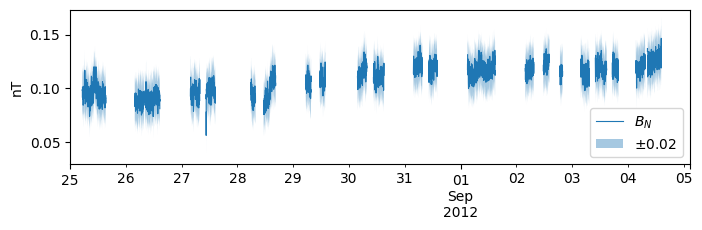

In [4]:
# Extract and plot the subset we'll study
v1_mag = data_res["BN"].iloc[:20000]
v1_err = 0.02

plt.figure(figsize=(8, 2))
v1_mag.plot(label="$B_N$", lw=0.8)

plt.fill_between(
    v1_mag.index,
    v1_mag - v1_err,
    v1_mag + v1_err,
    alpha=0.4,
    label=f"$\pm {v1_err}$",
)
plt.ylabel("nT")
plt.legend()

## Measurement error

Imprecision in the recording of data leads to measurement uncertainty. We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the 'true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$

This error $\epsilon$ can have two components: 

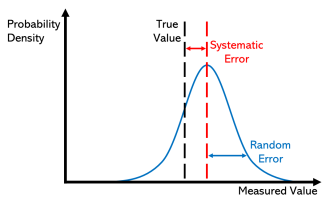 *From [Wikipedia](https://en.wikipedia.org/wiki/Observational_error)*
 
1. **systematic error**, which is generally a consistent offset to the true value (i.e., a *bias*). In this case of Voyager this results from issues around contamination by the spacecraft's magnetic field and telemetry errors, and comprises the majority of the error term. While it can generally be ignored since any bias is cancelled out when computing increments/fluctuations...

$$(X_1+b) - (X_2+b) = X_1 - X_2$$

...it can still warrant attention when it is not constant over time (i.e., subject to *drift*), as is the case with Voyager data. In this case it introduces low-frequency noise to the statistics, which requires something like a high-pass filter to remove.

2. **random error**. This is also referred to as *noise*, and in the case of magnetic field data usually results from instrument (thermal) noise and digitization errors. We always need to directly handle this error, and we will focus on this for the rest of this demonstration by denoting it as $\epsilon$.

Random error is typically assumed to be independent and identically distributed (i.i.d.) across all observations, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$, giving the blue curve in the figure from Wikipedia above.

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**Random error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$.

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$ and the independence of $X$ and $\epsilon$.

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $X_i, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

The full derivation of this is given in two astrophysics papers: [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf), Appendix A.3 and [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf), Appendix C. (In those papers, they represent $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$ as $\mathbf{\sigma}^2_{stat}$, to distinguish it from the systematic error variance $\mathbf{\sigma}^2_{sys}$.) They then show the subtraction of this bias in their Figures 3 and 5, respectively:

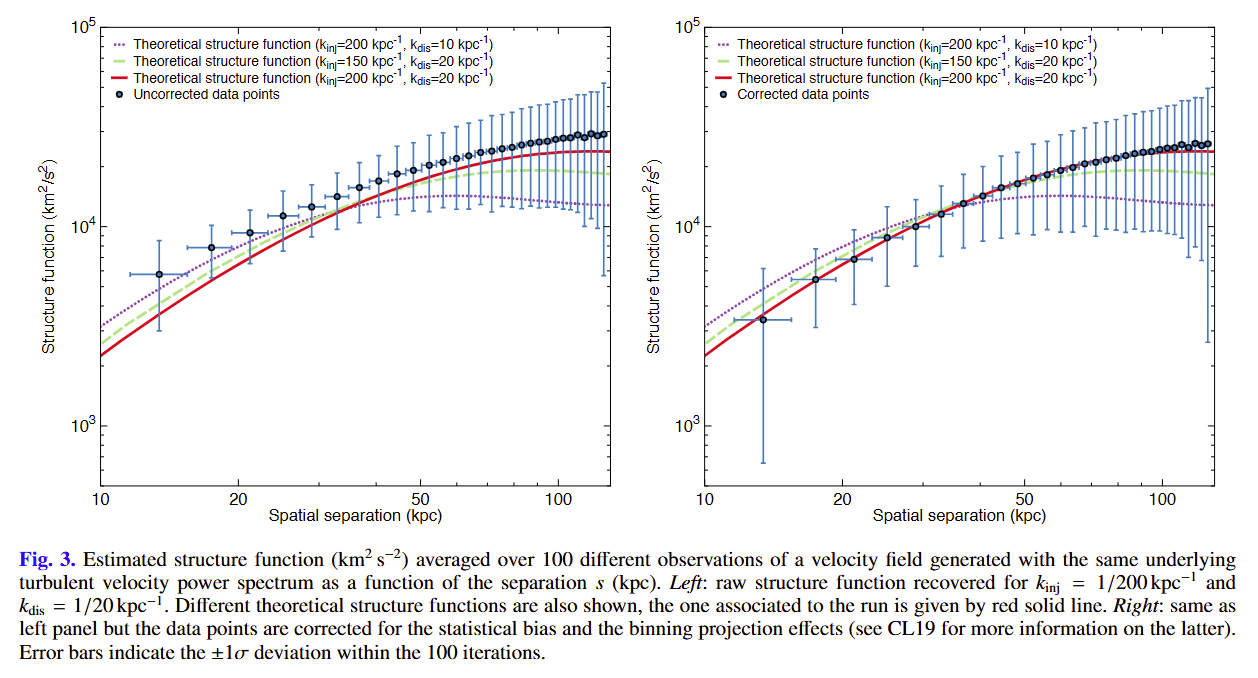

*^ From [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf). In the right panel we can see that after subtracting the bias, the points lie much more in line with the red theoretical model.*

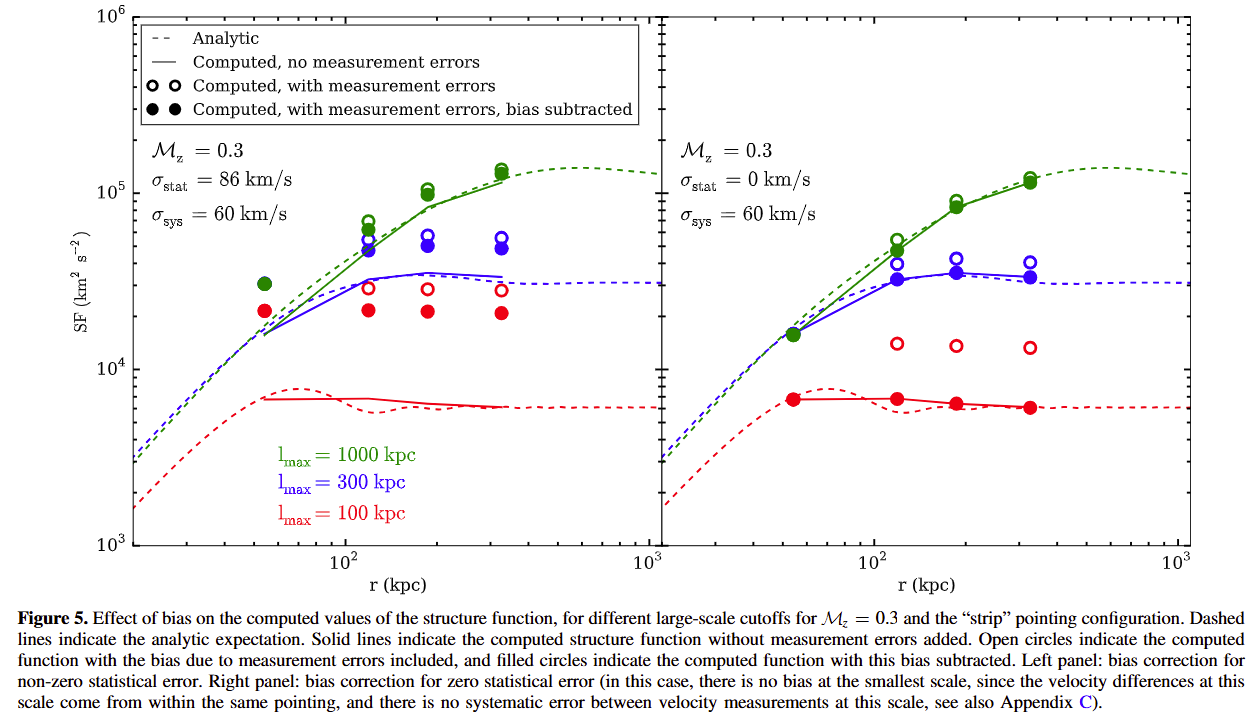

*^ From [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf). Again, measurement errors cause upwards bias. Bias is strongest for the structure function with a small injection scale (red line). Their systematic error describes an error which is a constant offset within a given chunk of data (and therefore cancels out), but varies across chunks ('pointings'), and therefore needs modelling with a variance $\sigma_{sys}$. Given it does often cancel out, overall we see that statistical error is the dominant contributor to the bias.*

The former paper also derives the error that propagates into the four-term *variance* of the structure function, which we need for calculating confidence intervals:

$$\text{Var}[\hat{\text{SF}}(\tau)]=\text{Var}[\text{SF}(\tau)]+4\text{Var}[\text{D}(\tau)]\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4}{N(\tau)}\text{SF}(\tau)\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4(N_{nei}(\tau)+1)}{N(\tau)}\mathbf{\sigma}_{\mathbf{\epsilon}}^4$$

where $D(\tau)$ is the increment function (first-order SF), $N(\tau)$ is the number of lag pairs at lag $\tau$, and $N_{nei}(\tau)$ is the number of neighbours at a distance of $\tau$ at any given point.

If we have zero uncertainty in the data, this variance reduces to a single term: the 'intrinsic variance' of the structure function $\text{Var}[\text{SF}(\tau)]$. This is the uncertainty that results from sampling, which will be discussed in the next section.

### Demo on simulated data
We can demonstrate the effect of measurement error by simulating it (given the error distribution), adding it to the time series, calculating the structure function, and doing this many times.

We can compare the effect of different amounts of error by specifying different signal-to-noise ratios (SNR), and then re-arranging to derive $\sigma_{\epsilon}$:

$$SNR=\frac{\text{Var}(\text{signal})}{\text{Var}\text{(noise)}}=\frac{\text{Var}(X)}{\sigma_{\epsilon}^2}$$

In [5]:
# Define function to "bootstrap" structure functions from time series with noise


def simulate_noise(x, max_lag, sigma_eps=None, snr=None, n_samples=1000, data_name="", plot_minus=False,  plot_noise_sf=False, log_axes=True):

    n = len(x)
    if sigma_eps is None:
        # Choose sigma such that the signal-to-noise ratio is snr
        sigma_eps = np.sqrt(np.var(x) / snr)
    if snr is None:
        # Calculate the signal-to-noise ratio
        snr = np.var(x) / sigma_eps**2

    # Remove any dated index (doesn't show up good in x-axis ticklabels)
    if type(x) == pd.Series:
        if type(x.index) == pd.DatetimeIndex:
            x.reset_index(drop=True, inplace=True)

    sf_true = sf_funcs.compute_sf(
        pd.DataFrame(x), np.arange(1, max_lag + 1), [2], False, False, None
    ).sf_2
    sf_noise = sf_funcs.compute_sf(
        pd.DataFrame(np.random.normal(0, sigma_eps, len(x))),
        np.arange(1, max_lag + 1),
        [2],
        False,
        False,
        None,
    ).sf_2

    sf_boot = np.zeros((n_samples, max_lag))

    x_boot_all = []

    for b in range(n_samples):

        x_boot = x + np.random.normal(0, sigma_eps, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(

            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None


        ).sf_2

    # PLOT RESULTS
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for x_boot in x_boot_all:
        ax[0].plot(x_boot, c="grey", alpha=0.1)
    ax[0].plot(
        x_boot[0],
        label=f"X +$\epsilon, \epsilon \sim N(0,\sigma^2_{{\epsilon}})$ ({n_samples} samples)",
        color="grey",
    )
    ax[0].plot(x, label=f"X ({data_name})", color="blue")
    # Reorder the legend
    handles, labels = ax[0].get_legend_handles_labels()
    handles = [handles[1], handles[0]]
    labels = [labels[1], labels[0]]
    ax[0].legend(handles, labels, loc="upper left")

    ci_lower = np.percentile(sf_boot, 2.5, axis=0)
    ci_upper = np.percentile(sf_boot, 97.5, axis=0)

    # Plot
    lags = np.arange(1, max_lag + 1)

    ax[1].plot(lags, sf_true, label="SF(X)", color="blue")

    if plot_noise_sf:
        sf_noise = sf_funcs.compute_sf(
            pd.DataFrame(np.random.normal(0, sigma_eps, len(ts))),
            np.arange(1, max_lag + 1),
            [2],
            False,
            False,
            None,
        )

        ax[1].plot(
            lags, sf_noise.sf_2, label="SF($\epsilon_i$)", color="pink", alpha=0.8, lw=0.8
        )

    if plot_minus:
        sf_corr = sf_true - 2 * sigma_eps**2
        sf_corr_pos = sf_corr[sf_corr > 0]
        lags_corr_pos = lags[sf_corr > 0]
        ax[1].plot(
            lags_corr_pos,
            sf_corr_pos,
            label="SF(X) - 2$\sigma_{\epsilon}^2$",
            color="black",
            linestyle="--",
        )

        # Set ylimits
        # ax[1].set_ylim(sf_corr.min(), sf_true.max())
    else:
        for sf in sf_boot:
            ax[1].plot(lags, sf, color="grey", alpha=0.2)
        ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(X + $\epsilon_i$)")
        ax[1].plot(
            lags,
            sf_true + 2 * sigma_eps**2,
            label="SF(X) + 2$\sigma_{\epsilon}^2$",
            color="purple",
            linestyle="--",
        )
    # ax[1].plot(
    #     sf_true.lag[2:10],
    #     0.008 * np.power(sf_true.lag[2:10], 2 / 3),
    #     label="$\\tau^{2/3}$",
    #     color="black",
    #     linestyle=":",
    #     alpha=0.3,
    # )

    # ax[0].set_ylim(ts.min()-0.01, ts.max()+0.01)
    ax[0].set_title(
        f"Time series with added noise: ${{\sigma}}_{{\epsilon}}=${sigma_eps:.3f}, SNR={snr:.2f}"
    )
    ax[1].set_title(f"Corresponding structure functions")

    ax[1].set_xlabel("Lag (τ)")
    if log_axes:
        ax[1].set_xscale("log")
        ax[1].set_yscale("log")
    else:
        ax[1].axhline(2 * sigma_eps**2, color="gray", linestyle=":", label="2$\sigma_{\epsilon}^2$")
    # ax[1].set_ylim(0.01, 10)
    ax[1].legend(loc="lower right")
    # ax[1].set_ylim(5e-7,2e-4)
    fig.tight_layout()
    plt.show()

    return sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps

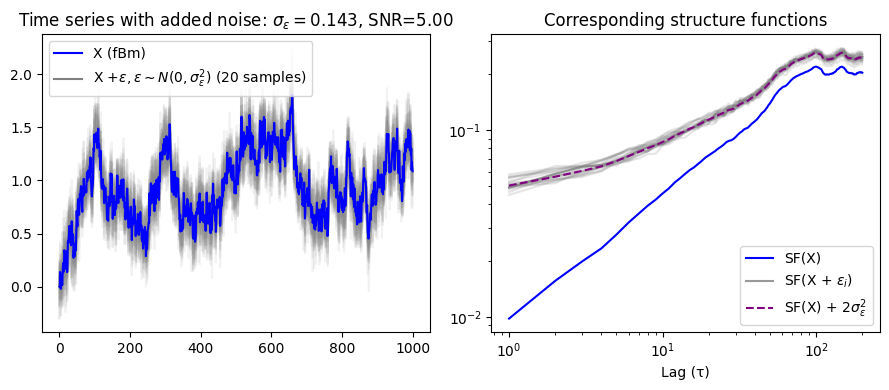

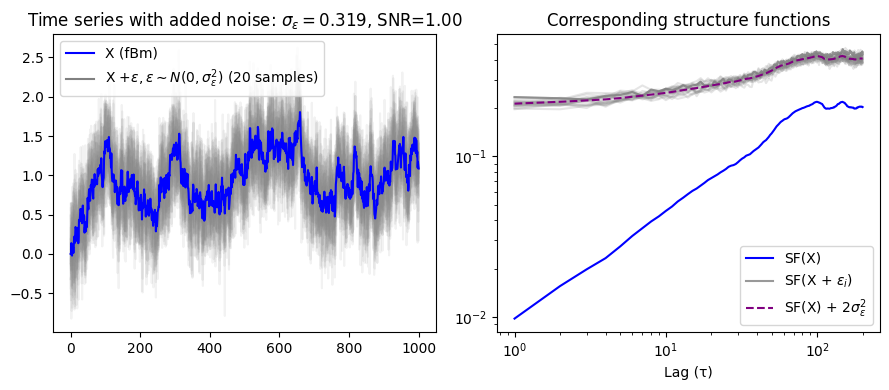

In [6]:
for snr in [5, 1]:
    sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
        x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="fBm"
    )

- The theoretical bias, given by the purple line in the right panel, matches very well with the results of our simulated noisy signals.
- Proportionally, measurement noise impacts small scales to a greater degree (small $\tau$) because that's where the signal differences are small. This scale-dependent effect results in a flattening of the curve in log-log space. **This will therefore lead to fitted slopes that are too small.**

### Demo on solar wind data

What we have with this real data is $\hat{\textbf{X}}$, not $\textbf{X}$, which means we should be *subtracting* $2\sigma_{\epsilon}^2$ from $\text{SF}$. We do this by changing an argument in the plotting function.

In [7]:
v1_err_stat = 0.005 # nT

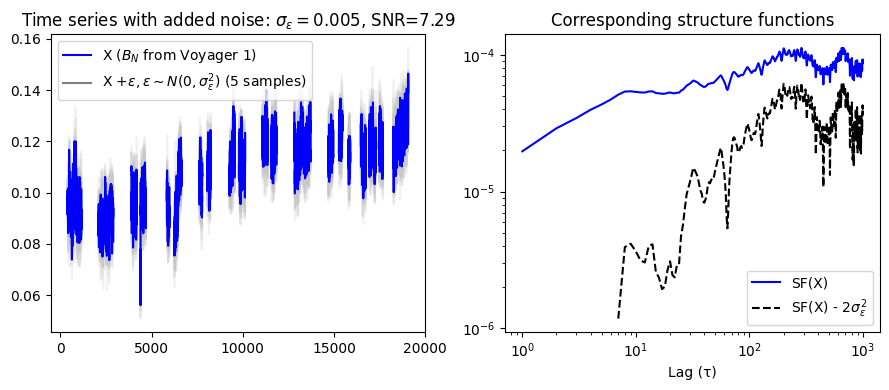

In [8]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=5,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=True
)

As expected, the corrected structure function is steeper. Note also we have had to disregard the first 6 lags where the corrected SF was smaller than zero.



What's particularly appealing about this correction is that it is independently verified by the jump in the SF at the origin. This y-intercept is theoretically equal to twice the variance of the noise, and is known as the *nugget* effect in geostatistics. We can observe this for our data by switching to linear axes.

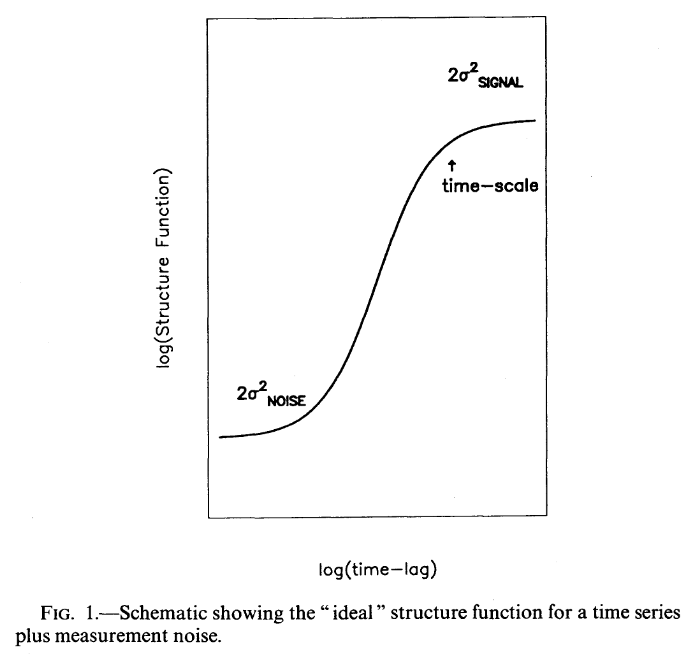 *From [Hughes et al., 1992](https://articles.adsabs.harvard.edu/cgi-bin/nph-iarticle_query?1992ApJ...396..469H&defaultprint=YES&page_ind=0&filetype=.pdf)*

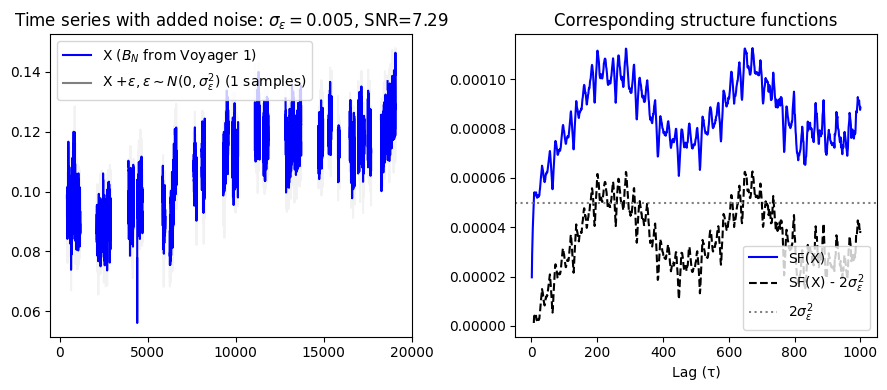

In [9]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=1,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=False,
)

As shown by the dotted horizontal line, this jump lines up extremely well with the reported measurement error.

*But what if we're averaging the data, or binning the SFs?*

## Sampling error

This is the error that occurs when statistics are estimated from a only a sample of the population. This error is unavoidable, but it is reduced by having a larger sample (or longer interval in the case of time series). 

In our case, we would like to know, given the stochastic nature of turbulence, if we were to observe a slightly different interval, how much could the SF/ACF/PSD - and in particular, its derived statistics, such as the inertial range slope or correlation time - differ?

The best way of expressing this uncertainty is via a distribution of the statistic, from which we can derive a confidence interval. But how do we do this, if we just have the one sample? In some cases, we can use statistical theory. In the most valid example, the central limit theorem gives us the distribution of the sample mean of a population.

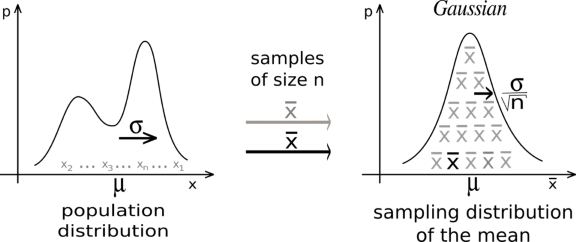 *From [Wikipedia](https://www.google.com/url?sa=i&url=https%3A%2F%2Fen.wikipedia.org%2Fwiki%2FCentral_limit_theorem&psig=AOvVaw2e_6Wx-rBfPtXMutDCfORo&ust=1746133492080000&source=images&cd=vfe&opi=89978449&ved=0CBcQjhxqFwoTCICzxarUgI0DFQAAAAAdAAAAABAE)*

We can use this asymptotic behaviour to derive a 95% confidence interval for the sample mean, i.e. $\bar{x}\pm1.96\sigma/n$.

These analytical formulas can provide insight into how uncertainty scales with sample size and variance. But these theoretical expressions often come with assumptions that may not always be valid. Bootstrapping is an alternative, largely-assumption free approach to generating the distribution of the sampling statistic. It involves generating new samples by resampling with replacement from the original data, and then calculating our statistic of interest from each of these. (The only assumption here is that the sample/interval is representative of the population, and therefore each new sample is plausible.)

### Bootstrapping residuals

For spectra, people have bootstrapped the fits by residual resampling. You just fit your power-law, then add the residuals to the fit and re-fit. This perturbs the amplitudes around the best-fit model 

Carbone likes to do this for Hilbert spectra, an equivalent way of getting SF scaling exponents ([Carbone et al., 2020](https://www.mdpi.com/2218-1997/6/8/116), Telloni et al. 2021, [Carbone et al. 2021](https://doi.org/10.1051/0004-6361/202140931)):

This method is indeed commonly used in the literature for slopes, and kurtosis in particular.


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

def plot_bootstrap_slopes(x, y, x_range=None, n_bootstrap=1000, random_seed=42):
    np.random.seed(random_seed)
    sns.set_theme(style="whitegrid", palette="colorblind", context="talk", font_scale=0.8)

    # Subset of data
    if x_range:
        mask = (x >= x_range[0]) & (x <= x_range[1])
        x_subset = x[mask]
        y_subset = y[mask]
    else:
        x_subset, y_subset = x, y

    slope_orig, intercept_orig, r_value, p_value, std_err = linregress(
        x_subset, y_subset
    )
    y_fit = intercept_orig + slope_orig * x_subset
    residuals = y_subset - y_fit

    # Bootstrap residuals
    slopes, intercepts = [], []
    for _ in range(n_bootstrap):
        resampled_resid = np.random.choice(residuals, size=len(residuals), replace=True)
        y_bootstrap = y_fit + resampled_resid
        s, i, *_ = linregress(x_subset, y_bootstrap)
        slopes.append(s)
        intercepts.append(i)

    slopes, intercepts = np.array(slopes), np.array(intercepts)

    y_boot_all = np.array(
        [intercepts[i] + slopes[i] * x_subset for i in range(n_bootstrap)]
    )
    ci_lower = np.percentile(y_boot_all, 2.5, axis=0)
    ci_upper = np.percentile(y_boot_all, 97.5, axis=0)
    slope_ci = np.percentile(slopes, [2.5, 97.5])

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
    axes = axes.flatten()

    # Panel A: Initial fit
    axes[0].scatter(x, y, alpha=0.4, c="gray", s=2)
    axes[0].scatter(x_subset, y_subset, alpha=0.6, c="black", s=2)
    axes[0].plot(
        x_subset, y_fit, label=f"Original slope = {slope_orig:.3f}", color="C1", lw=3
    )
    axes[0].set_title("Initial fit")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].legend()
    axes[0].grid(True, alpha=0.5)

    # Panel B: Bootstrap CI and slope distribution
    axes[1].plot(x, y, alpha=0.4, c="gray", marker="o", markersize=2, lw=0.5)
    axes[1].plot(
        x_subset, y_subset, alpha=0.6, c="black", marker="o", markersize=2, lw=0.5
    )
    axes[1].plot(x_subset, y_fit, color="C1", lw=3)
    axes[1].fill_between(
        x_subset,
        ci_lower,
        ci_upper,
        alpha=0.3,
        color="C1",
        label=f"Slope = ({slope_ci[0]:.3f}, {slope_ci[1]:.3f})",
    )
    axes[1].set_title("Final Bootstrap 95% CI")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].legend()
    axes[1].grid(True, alpha=0.5)

    # Inset: Histogram of slopes
    ax_inset = axes[1].inset_axes([0.6, 0.1, 0.35, 0.35])
    sns.histplot(slopes, kde=False, ax=ax_inset, bins=30, color="grey")
    ax_inset.set_ylabel("")
    ax_inset.axvline(slope_orig, color="C1", linestyle="--", label="Subset slope")
    ax_inset.axvspan(slope_ci[0], slope_ci[1], color="C1", alpha=0.3, label="95% CI")
    ax_inset.set_title("Slope Distribution", fontsize=12)
    ax_inset.tick_params(axis="x", labelsize=10)
    ax_inset.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax_inset.grid(False)

    # Panel C: Residuals vs. Fitted
    axes[2].scatter(y_fit, residuals, alpha=0.6, c="black")
    axes[2].axhline(0, color="C1")
    axes[2].set_title(r"$\it{Calculating\ Residuals}$")
    axes[2].set_xlabel("Fitted Values")
    axes[2].set_ylabel("Residuals")
    axes[2].grid(True, alpha=0.5)

    # Panel D: Bootstrap process (using stored slopes/intercepts)
    example_indices = np.random.choice(n_bootstrap, size=10, replace=False)
    colors = sns.color_palette("husl", 10)
    x_ordered = np.sort(x_subset)

    axes[3].plot(
        x_subset,
        y_subset,
        color="black",
        alpha=0.8,
        label="Original data",
        marker="o",
        markersize=3,
        lw=1,
    )
    for i, idx in enumerate(example_indices):
        slope_i = slopes[idx]
        intercept_i = intercepts[idx]
        y_boot_fit = intercept_i + slope_i * x_ordered

        # Simulated y_boot data (optional visual aid)
        y_boot = y_fit + np.random.choice(residuals, size=len(residuals), replace=True)
        axes[3].plot(
            x_subset,
            y_boot,
            color=colors[i],
            alpha=0.6,
            marker="o",
            markersize=2,
            lw=0.5,
        )
        axes[3].plot(x_ordered, y_boot_fit, color=colors[i], linewidth=2.5, alpha=0.8)

    axes[3].plot(x_subset, y_fit, linewidth=2, color="C1")
    axes[3].set_title(r"$\it{Adding\ Bootstrapped\ Residuals\ and\ Refitting}$")
    axes[3].set_xlabel("X")
    axes[3].set_ylabel("Y")
    axes[3].legend()
    axes[3].grid(True, alpha=0.5)

    # Add subplot labels
    labels = ["A", "D", "B", "C"]
    for ax, label in zip(axes, labels):
        ax.text(
            -0.1,
            1.1,
            label,
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            va="top",
            ha="right",
        )

    # Print numerical results
    print(f"Original slope: {slope_orig:.6f}")
    print(f"95% CI for slope: [{slope_ci[0]:.6f}, {slope_ci[1]:.6f}]")
    print(f"R-squared: {r_value**2:.6f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Standard error: {std_err:.6f}")

    #plt.savefig("bootstrap_slopes.png", dpi=300, bbox_inches="tight")


#### Demo on simulated data

Original slope: 0.663810
95% CI for slope: [0.654725, 0.673325]
R-squared: 0.997556
p-value: 0.000000


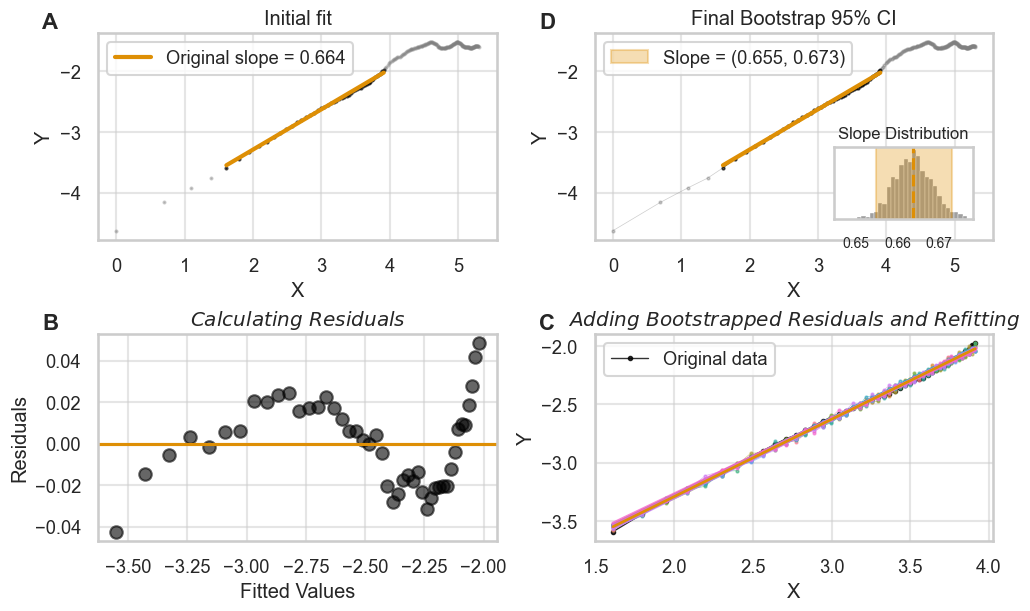

In [11]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

plot_bootstrap_slopes(np.log(sf_true.lag), np.log(sf_true.sf_2), x_range=(np.log(5),np.log(50)), n_bootstrap=1000)

#### Demo on solar wind data

In [12]:
max_lag = 1000

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(v1_mag), np.arange(1, max_lag + 1), [2], True, False, None
)

In [55]:
# Theoretical CI
0.72-1.96*0.001, 0.72+1.96*0.001 # 95% CI for slope

(0.71804, 0.7219599999999999)

Original slope: 0.720037
95% CI for slope: [0.718088, 0.721983]
R-squared: 0.998180
p-value: 0.000000
Standard error: 0.000988


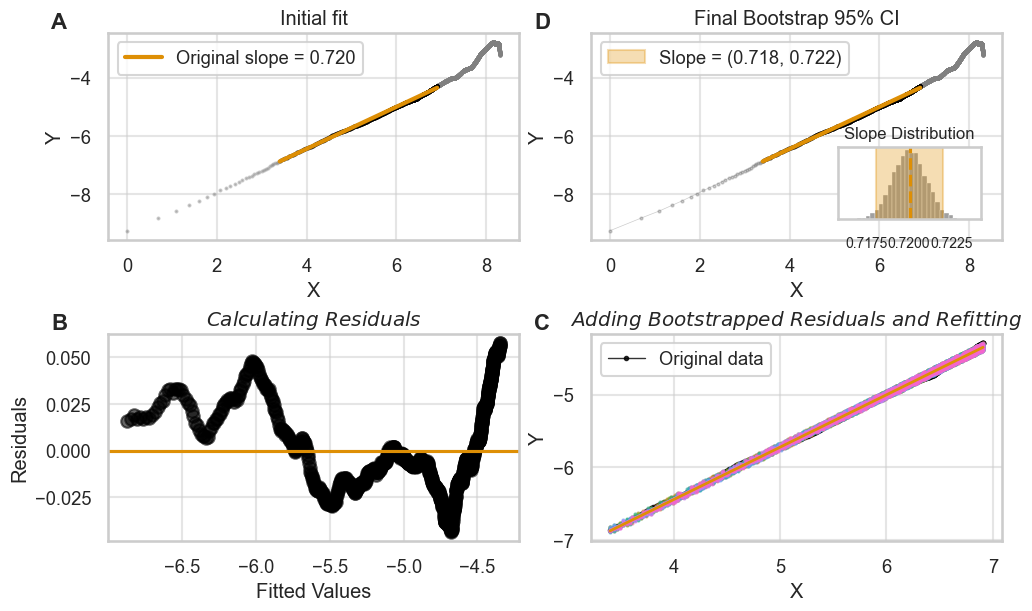

In [53]:
plot_bootstrap_slopes(
    np.log(sf_v1.lag),
    np.log(sf_v1.sf_2),
    x_range=(np.log(30), np.log(1000)),
    n_bootstrap=1000,
)

### Bootstrapping increments

We may also want to get a distribution of the structure functions themselves, i.e. to get an uncertainty at each lag.

Naively, we could bootstrap the squared increments at each lag, and use these to generate an ensemble of SFs from a single SF. 

We can then compare these with the theoretical distribution of the sample variance, which is what we are estimating at each lag with the second-order structure function. In the ideal case of Gaussian data, [the sample variance follows a scaled chi-squared distribution](https://en.wikipedia.org/wiki/Variance#Population_variance_and_sample_variance). The standard error of the sample variance $S^2$ is then given by:

$$
\hat{\sigma}_{S^2} = S^2 \sqrt{\frac{2}{n - 1}}
$$

Applied to the structure function, this gives an approximate standard error:

$$
\sigma_{\text{SF}}(\tau) = \text{SF}(\tau) \sqrt{\frac{2}{N(\tau) - 1}}
$$

where $N(\tau)$ is the number of increment pairs at lag $\tau$. (As for what we specifically get when this variance is of the difference of two squared RVs: this has been derived by [Clec et al. (2019, Appendix F)](https://www.aanda.org/articles/aa/abs/2019/09/aa35676-19/aa35676-19.html) and [Ortiz & Deutsch (2002)](https://link.springer.com/article/10.1023/A:1014412218427).)


In [70]:
def get_lag_vals_list(df):
    lag_vals_wide = pd.DataFrame(df["diffs_2"].tolist(), index=df.index)
    lag_vals_wide.reset_index(inplace=True)  # Make the index a column
    lag_vals_wide.rename(columns={"index": "lag"}, inplace=True)
    lag_vals = pd.melt(
        lag_vals_wide, id_vars=["lag"], var_name="index", value_name="diffs_2"
    )
    return lag_vals

In [38]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

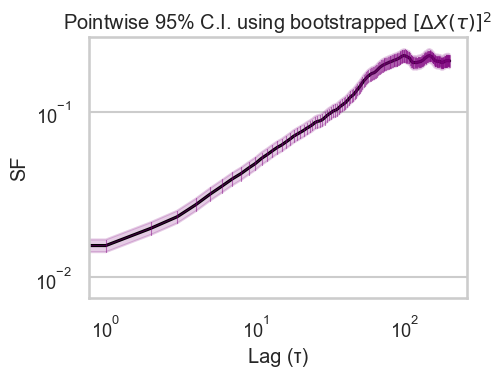

In [ ]:
lags = np.arange(1, max_lag + 1)


# Calculate standard error assuming chi-squared approximation (pointwise error bars)

n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_true.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_true.sf_2 - 1.96 * sf_se
ci_se_upper = sf_true.sf_2 + 1.96 * sf_se


# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lags - 1, sf_true.sf_2, color="black")
lag_vals = get_lag_vals_list(sf_true)

# TAKES AGES FOR VOYAGER
sns.pointplot(
    x="lag",
    y="diffs_2",
    data=lag_vals,
    alpha=0.5,
    errorbar="ci",
    n_boot=1000,
    marker=None,
    c="purple",
    ax=ax,
    estimator="mean",
    lw=0.8,
)


ax.fill_between(
    lags - 1,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.2,
)


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF")
ax.set_title("Pointwise 95% C.I. using bootstrapped $[\Delta X(\\tau)]^2$")

ax.set_xscale("log")
ax.set_yscale("log")

fig.tight_layout()

plt.show()

The confidence interval based on the theoretical standard error of the sample variance, is approximately equal to the bootstrap confidence interval at a given lag (i.e., resampling with replacement the squared increments at that lag.) *This suggests that the raw differences are Gaussian enough, or the sample sizes large enough, for this convergence to occur.*

**However, both this and the residual bootstrapping are underestimates of the uncertainty.** They both miss a vital fact about the data: data points, and therefore differences and fitting residuals, are not independent. Pointwise confidence that we are currently expressing, either via analytical formulas or numerical simulation is inappropriate, and under-estimating the true uncertainty. In order to handle the serial correlation between lags, we need a method of calculating *joint* confidence intervals.

Therefore, bootstrapping of the underlying differences at each lag is inappropriate. This is actually a problem for the residual bootstrapping as well, which assumes residuals are independendent of one another.

Therefore, how do we bootstrap better?

Generate an ensemble of SFs using 

1. **Bootstrap the wavelet leaders of the data, which are only weakly correlated.** This is the most robust but most complicated method, and requires evenly-spaced data. 
2. **Bootstrap the original time series in blocks.** This requires careful setting of the block size in order to preserve sufficient autocorrelation properties.

### Jack-knifing time series
This is like bootstrapping but it uses subsets of the original sample, rather than re-samples of the same size. This was used for estimating the error in structure function scaling exponents and kurtosis by [Bowen et al. (2023)](https://doi.org/10.1038/s41550-023-02186-4) and [Grošelj et al. (2019)](https://journals.aps.org/prx/pdf/10.1103/PhysRevX.9.031037)


### Bootstrapping wavelet leaders

A very relevant method has been developed which resamples not the increments, nor blocks of the time series, but the *wavelet leaders* of the time series. These are only weakly correlated. From these, the SFs and their corresponding slopes are estimated. It is described in depth, with turbulence analysis in mind, by Wendt. It is applied to ionospheric turbulence by [Golovchanskaya & Kozelov (2010)](https://agupubs.onlinelibrary.wiley.com/doi/pdfdirect/10.1029/2009JA014632)

### Bootstrapping time series

One way that has been suggested for dealing with autocorrelation is *block bootstrapping*. Doing this in blocks preserves at least *some* of the correlation structure. However, it does not preserve long-run correlations, *and* it can lead to discontinuities at the boundaries between blocks.

Block bootstrapping perserves short-to-intermediate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

See implementation for turbulence by [Garcia et al. (2006)](https://www.researchgate.net/publication/226512042_Confidence_intervals_in_the_determination_of_turbulence_parameters?enrichId=rgreq-820047523ef292f260b72c186904cc56-XXX&enrichSource=Y292ZXJQYWdlOzIyNjUxMjA0MjtBUzoxMDI5OTc1MjY4NDMzOThAMTQwMTU2NzkzMjQzNg%3D%3D&el=1_x_2&_esc=publicationCoverPdf)

#### Demo on simulated data

In [57]:
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None, plot=True, n_samples=3, data_name=""):

    def block_matches_with_na(block1, block2):
        """
        Check if two blocks match, accounting for NA values.
        Two blocks match if:
        1. Non-NA values in the same positions are close to each other
        2. NA patterns match (NA in block1 corresponds to NA in block2)
        """
        import numpy as np
        import pandas as pd

        # Convert to numpy arrays if they aren't already
        block1 = np.array(block1)
        block2 = np.array(block2)

        # Check if lengths match
        if len(block1) != len(block2):
            return False

        # Create masks for NA values
        mask1 = pd.isna(block1)
        mask2 = pd.isna(block2)

        # Check if NA patterns match
        if not np.array_equal(mask1, mask2):
            return False

        # For non-NA values, check if they are close
        non_na_indices = ~mask1  # Same as ~mask2 since we've verified they're equal

        # If all values are NA, blocks match
        if not np.any(non_na_indices):
            return True

        # Check if non-NA values are close
        return np.allclose(block1[non_na_indices], block2[non_na_indices], atol=1e-6)

    if random_state is not None:
        np.random.seed(random_state)


    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):

        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(


            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )


        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    # return sf_boot, x_boot_all

    if plot:
        n = len(x)
        n_blocks = n // block_size

        fig, axes = plt.subplots(
            n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
        )

        # --- x Time Series ---
        ax0 = axes[0]
        # Plot non-NA values and indicate NA values
        valid_mask = ~pd.isna(x)
        ax0.plot(np.arange(n), np.array(x), color="black")

        for i in range(n_blocks):
            start = i * block_size
            ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

            ypos = np.nanmax(x) * 0.5
            if np.isnan(ypos):  # Handle case where all data might be NaN
                ypos = 0.5

            ax0.text(
                start + block_size / 2,
                ypos,
                f"{i}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            )
        ax0.set_title(
            f"Original time series ({data_name}) with block indices", fontweight="bold"
        )
        ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

        # --- Bootstrapped Samples ---
        for sample_idx in range(n_samples):
            sample = x_boot_all[sample_idx]
            ax = axes[sample_idx + 1]

            # Plot non-NA values in the bootstrap sample
            valid_mask_sample = ~pd.isna(sample)
            if np.any(valid_mask_sample):
                ax.plot(
                    np.arange(len(sample)),
                    np.array(sample),
                    color="black",
                    lw=0.5,
                )

            # Mark NA positions in bootstrap sample
            for i in range(0, len(sample), block_size):
                block = sample[i : i + block_size]

                # Identify origin block
                found_origin = -1
                for j in range(n_blocks):
                    orig_block = x[j * block_size : (j + 1) * block_size]
                    orig_block_size = min(block_size, len(orig_block))

                    # Compare blocks accounting for NAs
                    if block_matches_with_na(
                        block[:orig_block_size], orig_block[:orig_block_size]
                    ):
                        found_origin = j
                        break

                ax.axvline(i, linestyle="--", alpha=0.7, color="black")

                ypos = np.nanmax(sample) * 0.5
                if np.isnan(ypos):  # Handle case where all data might be NaN
                    ypos = 0.5

                ax.text(
                    i + block_size / 2,
                    ypos,
                    f"{found_origin}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    bbox=dict(
                        facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                    ),
                )

            # Add final vertical line for the last block
            ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
            ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

        plt.tight_layout()
        plt.show()

    return sf_boot, x_boot_all

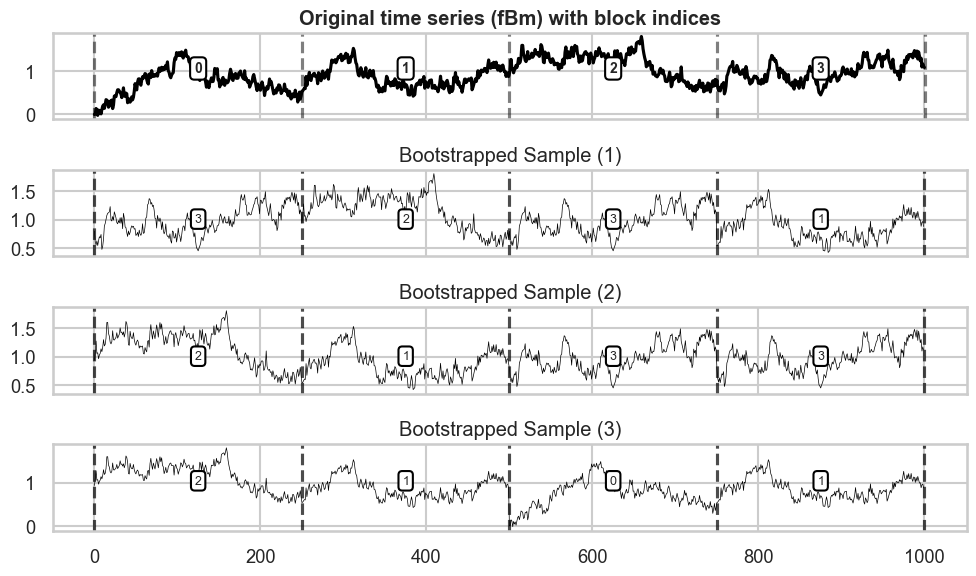

In [86]:
# Parameters
block_size = 250
n_bootstraps = 50
max_lag = 200

# Compute original SF and bootstrapped confidence intervals
ts = ts_sim

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps, data_name="fBm")

# Fit a power law to each bootstrap sample
def fit_power_law(x, y, x_range=None):
    if x_range is not None:
        mask = (x >= x_range[0]) & (x <= x_range[1])
        x = x[mask]
        y = y[mask]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return slope, intercept, r_value**2, p_value, std_err

In [99]:
# Implement for each bootstrap sample
slopes = []
for i in range(n_bootstraps):
    slope, intercept, r2, p_val, std_err = fit_power_law(
        np.log(lags), np.log(sf_boot[i]), (np.log(5), np.log(50))
    )
    slopes.append(slope)

slope_orig, *_ = fit_power_law(np.log(lags), np.log(sf_true.sf_2), (np.log(5), np.log(50)))

slope_ci_lower = np.percentile(slopes, 2.5)
slope_ci_upper = np.percentile(slopes, 97.5)

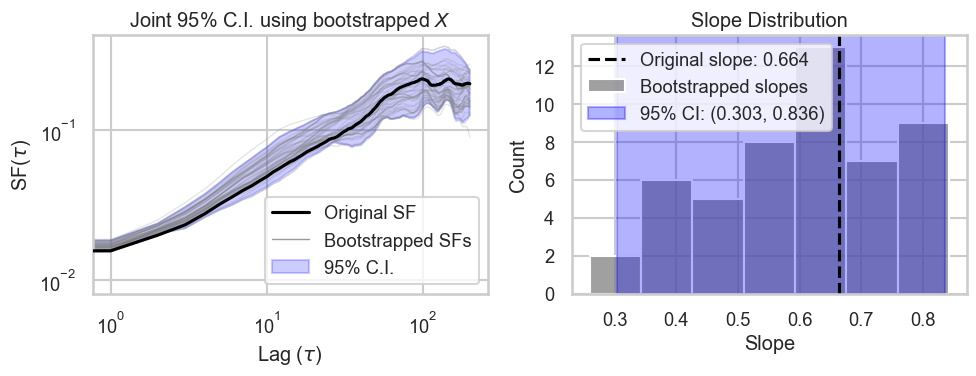

In [118]:
sf_ci_lower = np.percentile(sf_boot, 2.5, axis=0)
sf_ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.plot(lags - 1, sf_true.sf_2, label="Original SF", color="black", zorder=10)

for sf in sf_boot:
    ax.plot(lags-1, sf, color="grey", alpha=0.2, lw=1)
ax.plot(
    lags[0] - 1, sf_boot[0][0], color="grey", alpha=0.8, lw=1, label="Bootstrapped SFs"
)

ax.set_xlabel("Lag ($\\tau$)")
ax.set_ylabel("SF($\\tau$)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Joint 95% C.I. using bootstrapped $X$")

ax.fill_between(lags - 1, sf_ci_lower, sf_ci_upper, color="blue", alpha=0.2, label="95% C.I.")
ax.legend(loc="lower right")

ax2 = axes[1]
sns.histplot(slopes, kde=False, color="grey", ax=ax2, label="Bootstrapped slopes")
ax2.axvline(slope_orig, color="black", linestyle="--", label=f"Original slope: {slope_orig:.3f}")
ax2.axvspan(
    slope_ci_lower,
    slope_ci_upper,
    color="blue",
    alpha=0.3,
    label=f"95% CI: ({slope_ci_lower:.3f}, {slope_ci_upper:.3f})",
)
ax2.set_title(f"Slope Distribution")
# Reorder legend
handles, labels = ax2.get_legend_handles_labels()
handles = [handles[0], handles[2], handles[1]]
labels = [labels[0], labels[2], labels[1]]
ax2.legend(handles, labels)
ax2.set_xlabel("Slope")

fig.tight_layout()
plt.show()

# Bonus
Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

In [45]:
data_res = data_full.resample("1d").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


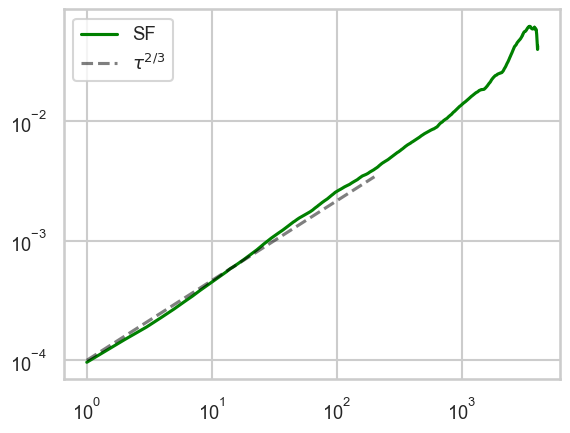

In [46]:
max_lag = 2000

sf_v1 = sf_funcs.compute_sf(
    data_res[["BR", "BT", "BN"]], np.arange(1, len(data_res)), [2], False, False, None
)

plt.plot(
    sf_v1.lag,
    sf_v1.sf_2,
    label="SF",
    color="green",
)

# Plot 2/3 power law
plt.plot(
    sf_true.lag,
    0.0001 * np.power(sf_true.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)
plt.legend()
plt.xscale("log")
plt.yscale("log")

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)